In [2]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#read data
#upload news and price data
news = pd.read_csv('data/news/all_news.csv', date_format='pubDate')
price = pd.read_csv('data/all_zec.csv')
print('before dedup', news.shape, price.shape)
#normalize timestamps
price['timestamp'] = pd.to_datetime(price['timestamp'], utc=True)
news['pubDate'] = pd.to_datetime(news['pubDate'], utc=True)
news['fetched_at'] = pd.to_datetime(news['fetched_at'], utc=True)
news = news.drop_duplicates(subset='article_id')
news = news.sort_values(by = 'pubDate').reset_index(drop=True)
price = price.drop_duplicates(subset='timestamp')
price = price.set_index('timestamp').sort_index()
print('after_dedup (news df already was dedupped)', news.shape, price.shape)

before dedup (7857, 23) (28644, 4)
after_dedup (news df already was dedupped) (7857, 23) (23349, 3)


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.dates as mdates

# --- 1. Use 30-min resampled price for a cleaner series ---
p = price['price'].resample('30min').mean().dropna().rename('price')

# --- 2. Build lag features (autoregressive) ---
lags = [1, 2, 3, 6, 12, 24]   # in 30-min units: up to 12h back
df_model = pd.DataFrame({'price': p})
for lag in lags:
    df_model[f'lag_{lag}'] = df_model['price'].shift(lag)
df_model = df_model.dropna()

X = df_model[[f'lag_{l}' for l in lags]].values
y = df_model['price'].values
dates = df_model.index

# --- 3. Chronological train/test split (80/20) ---
split = int(len(df_model) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = dates[split:]

# --- 4. Fit linear regression ---
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- 5. Metrics ---
mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
naive_rmse = root_mean_squared_error(y_test[1:], y_test[:-1])   # persistence baseline
print(f"MAE:        {mae:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"Naive RMSE: {naive_rmse:.4f}  (predict last value)")


MAE:        1.4726
RMSE:       2.7373
Naive RMSE: 2.6653  (predict last value)


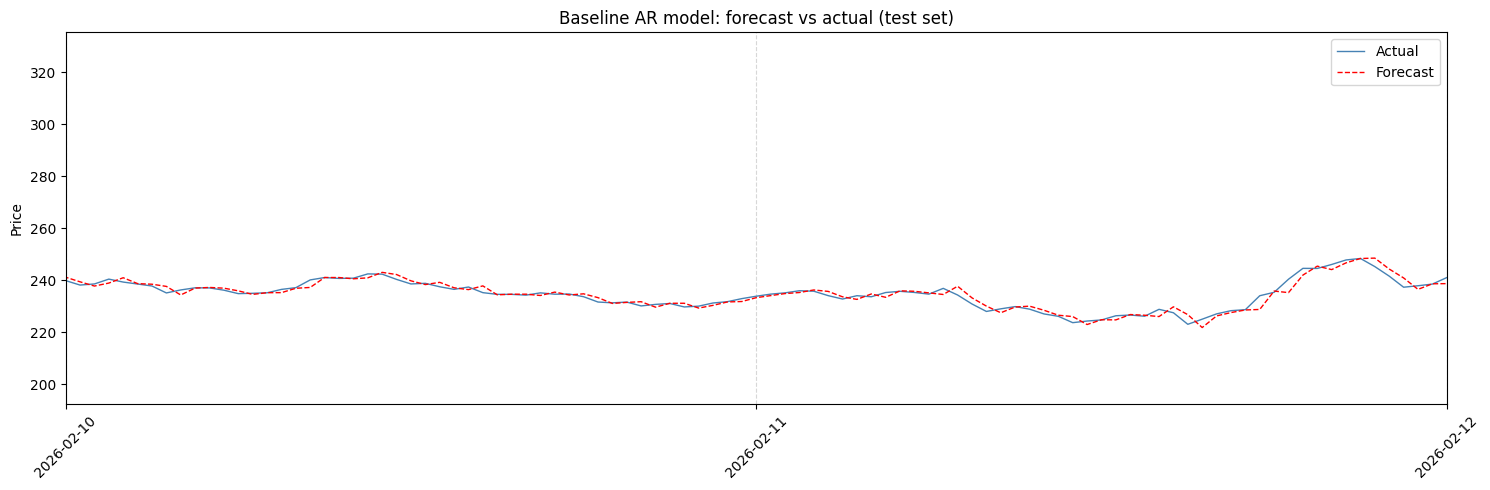

In [5]:

# --- 6. Plot forecast vs actual ---
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(dates_test, y_test, label='Actual',    color='steelblue', linewidth=1)
ax.plot(dates_test, y_pred, label='Forecast',  color='red',       linewidth=1, linestyle='--')

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_ylabel('Price')
ax.set_title('Baseline AR model: forecast vs actual (test set)')
ax.legend()
plt.xlim(pd.to_datetime('Feb-10-2026'), pd.to_datetime('Feb-12-2026'))
plt.tight_layout()
plt.show()